In [1]:
!pip install -q kagglehub thop xgboost

In [5]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset is here:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset is here: /kaggle/input/skin-cancer-mnist-ham10000


In [6]:
import os

for item in os.listdir(path):
    print(item)

hmnist_8_8_RGB.csv
hmnist_28_28_RGB.csv
HAM10000_images_part_1
ham10000_images_part_1
hmnist_8_8_L.csv
HAM10000_images_part_2
ham10000_images_part_2
hmnist_28_28_L.csv
HAM10000_metadata.csv


In [7]:
import pandas as pd
import glob

csv_file = glob.glob(os.path.join(path, "**", "HAM10000_metadata.csv"), recursive=True)[0]
df = pd.read_csv(csv_file)
print("Total rows:", len(df))
df.head(10)

Total rows: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


In [8]:
print(df["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Total images: 20030


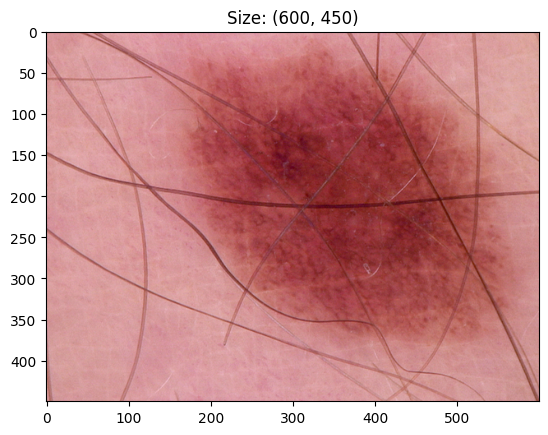

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img_files = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)
print("Total images:", len(img_files))

img = Image.open(img_files[0])
plt.imshow(img)
plt.title(f"Size: {img.size}")
plt.show()

Connect images to labels

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

# Map each image_id to its file path
img_dict = {}
for f in img_files:
    name = os.path.splitext(os.path.basename(f))[0]
    img_dict[name] = f

df["filepath"] = df["image_id"].map(img_dict)
df = df.dropna(subset=["filepath"])
print("Images matched:", len(df))

Images matched: 10015


Convert disease names to numbers (0–6)

In [11]:
CLASSES = sorted(df["dx"].unique())
print("Classes:", CLASSES)

df["label"] = df["dx"].map({c: i for i, c in enumerate(CLASSES)})
print(df[["dx", "label"]].drop_duplicates().sort_values("label"))

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
         dx  label
9687  akiec      0
2462    bcc      1
0       bkl      2
1095     df      3
1211    mel      4
64       nv      5
2320   vasc      6


Split into train (80%), validation (10%), test (10%)

In [12]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

Train: 8012
Val:   1001
Test:  1002


Create PyTorch Dataset (this is how we feed images to models)

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Resize all images to 224x224, convert to tensor, normalize
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class SkinDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        image = self.transform(image)
        label = int(row["label"])
        return image, label

# Create datasets
train_dataset = SkinDataset(train_df, train_transform)
val_dataset   = SkinDataset(val_df, test_transform)
test_dataset  = SkinDataset(test_df, test_transform)

# Create dataloaders (feeds images in batches of 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

print("Batches - Train:", len(train_loader),
      "Val:", len(val_loader),
      "Test:", len(test_loader))

Batches - Train: 251 Val: 32 Test: 32


In [14]:
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)   # should be [32, 3, 224, 224]
print("Labels:", labels[:10])          # first 10 labels

Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([5, 5, 5, 1, 4, 5, 2, 5, 5, 4])


**Train your first model (ResNet18)**
Load a pretrained ResNet18 and modify it

In [15]:
import torch.nn as nn
from torchvision import models

# Load ResNet18 pretrained on ImageNet (millions of general images)
model = models.resnet18(weights="DEFAULT")

# The last layer outputs 1000 classes (ImageNet).
# We need 7 classes (our skin diseases). So we replace it:
model.fc = nn.Linear(model.fc.in_features, 7)

# Move to GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print("Using:", device)
print("Last layer:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 54.6MB/s]


Using: cuda
Last layer: Linear(in_features=512, out_features=7, bias=True)


Set up training tools

In [16]:
# Class weights — give more importance to rare diseases
counts = np.bincount(train_df["label"].values, minlength=7)
weights = torch.tensor(len(train_df) / (7 * counts), dtype=torch.float).to(device)
print("Class weights:", weights.round(decimals=2))

# Loss function (measures how wrong the model is)
criterion = nn.CrossEntropyLoss(weight=weights)

# Optimizer (updates the model to reduce loss)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Class weights: tensor([ 4.3700,  2.7800,  1.3000, 12.4400,  1.2900,  0.2100, 10.0400],
       device='cuda:0')


Training for epchs

In [18]:
# Reset model (fresh start with 12 epochs)
model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 7)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

best_val_acc = 0
EPOCHS = 15

for epoch in range(EPOCHS):

    # --- TRAINING ---
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    # --- VALIDATION ---
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_best.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {train_acc:.1f}% | "
          f"Val Acc: {val_acc:.1f}% {'★ saved' if val_acc >= best_val_acc else ''}")

print(f"\nBest Validation Accuracy: {best_val_acc:.1f}%")

Epoch 1/15 | Train Loss: 1.062 | Train Acc: 60.3% | Val Acc: 67.8% ★ saved
Epoch 2/15 | Train Loss: 0.697 | Train Acc: 71.5% | Val Acc: 76.0% ★ saved
Epoch 3/15 | Train Loss: 0.541 | Train Acc: 76.8% | Val Acc: 76.9% ★ saved
Epoch 4/15 | Train Loss: 0.473 | Train Acc: 78.1% | Val Acc: 77.5% ★ saved
Epoch 5/15 | Train Loss: 0.368 | Train Acc: 82.0% | Val Acc: 79.8% ★ saved
Epoch 6/15 | Train Loss: 0.347 | Train Acc: 82.6% | Val Acc: 76.4% 
Epoch 7/15 | Train Loss: 0.304 | Train Acc: 84.0% | Val Acc: 82.2% ★ saved
Epoch 8/15 | Train Loss: 0.240 | Train Acc: 87.2% | Val Acc: 80.0% 
Epoch 9/15 | Train Loss: 0.231 | Train Acc: 87.8% | Val Acc: 78.3% 
Epoch 10/15 | Train Loss: 0.238 | Train Acc: 87.1% | Val Acc: 74.3% 
Epoch 11/15 | Train Loss: 0.238 | Train Acc: 87.8% | Val Acc: 83.8% ★ saved
Epoch 12/15 | Train Loss: 0.152 | Train Acc: 90.7% | Val Acc: 85.0% ★ saved
Epoch 13/15 | Train Loss: 0.130 | Train Acc: 91.6% | Val Acc: 84.5% 
Epoch 14/15 | Train Loss: 0.116 | Train Acc: 93.1% | Val

Test the model (get Table 1 numbers)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load the best saved model
model.load_state_dict(torch.load("resnet18_best.pth"))
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Calculate all 5 metrics
accuracy  = 100 * accuracy_score(all_labels, all_preds)
precision = 100 * precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall    = 100 * recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1        = 100 * f1_score(all_labels, all_preds, average="weighted", zero_division=0)
auc       = 100 * roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")

print("========= ResNet18 — Test Results =========")
print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1-Score:  {f1:.2f}%")
print(f"AUC:       {auc:.2f}%")

========= ResNet18 — Test Results =========
Accuracy:  86.53%
Precision: 86.76%
Recall:    86.53%
F1-Score:  86.59%
AUC:       96.94%


In [20]:
# --- AlexNet ---
model2 = models.alexnet(weights="DEFAULT")
model2.classifier[6] = nn.Linear(4096, 7)
model2 = model2.to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)

best_val_acc2 = 0

for epoch in range(12):
    model2.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model2(images)
        loss = criterion(outputs, labels)
        optimizer2.zero_grad(); loss.backward(); optimizer2.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model2.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc2:
        best_val_acc2 = val_acc
        torch.save(model2.state_dict(), "alexnet_best.pth")

    print(f"Epoch {epoch+1}/12 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc2 else ''}")

Epoch 1/12 | Loss: 1.323 | Train Acc: 57.1% | Val Acc: 50.4% ★
Epoch 2/12 | Loss: 1.040 | Train Acc: 60.6% | Val Acc: 73.1% ★
Epoch 3/12 | Loss: 0.892 | Train Acc: 65.7% | Val Acc: 60.5%
Epoch 4/12 | Loss: 0.810 | Train Acc: 68.0% | Val Acc: 59.0%
Epoch 5/12 | Loss: 0.775 | Train Acc: 68.7% | Val Acc: 71.5%
Epoch 6/12 | Loss: 0.729 | Train Acc: 68.9% | Val Acc: 69.0%
Epoch 7/12 | Loss: 0.608 | Train Acc: 72.7% | Val Acc: 72.7%
Epoch 8/12 | Loss: 0.600 | Train Acc: 73.3% | Val Acc: 75.8% ★
Epoch 9/12 | Loss: 0.607 | Train Acc: 72.7% | Val Acc: 65.9%
Epoch 10/12 | Loss: 0.521 | Train Acc: 74.6% | Val Acc: 74.2%
Epoch 11/12 | Loss: 0.450 | Train Acc: 77.6% | Val Acc: 72.2%
Epoch 12/12 | Loss: 0.445 | Train Acc: 78.4% | Val Acc: 73.6%


In [21]:
model2.load_state_dict(torch.load("alexnet_best.pth"))
model2.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model2(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= AlexNet — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

========= AlexNet — Test Results =========
Accuracy:  75.45%
Precision: 80.54%
Recall:    75.45%
F1-Score:  77.06%
AUC:       95.10%


VGG16

In [22]:
# --- VGG16 ---
model3 = models.vgg16(weights="DEFAULT")
model3.classifier[6] = nn.Linear(4096, 7)
model3 = model3.to(device)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0001)

best_val_acc3 = 0

for epoch in range(12):
    model3.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model3(images)
        loss = criterion(outputs, labels)
        optimizer3.zero_grad(); loss.backward(); optimizer3.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model3.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model3(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc3:
        best_val_acc3 = val_acc
        torch.save(model3.state_dict(), "vgg16_best.pth")

    print(f"Epoch {epoch+1}/12 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc3 else ''}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 89.4MB/s]


Epoch 1/12 | Loss: 1.740 | Train Acc: 45.9% | Val Acc: 62.1% ★
Epoch 2/12 | Loss: 1.377 | Train Acc: 50.5% | Val Acc: 20.0%
Epoch 3/12 | Loss: 1.199 | Train Acc: 53.5% | Val Acc: 65.0% ★
Epoch 4/12 | Loss: 1.088 | Train Acc: 58.6% | Val Acc: 70.3% ★
Epoch 5/12 | Loss: 1.034 | Train Acc: 59.2% | Val Acc: 65.3%
Epoch 6/12 | Loss: 0.991 | Train Acc: 60.8% | Val Acc: 56.8%
Epoch 7/12 | Loss: 0.929 | Train Acc: 61.8% | Val Acc: 60.9%
Epoch 8/12 | Loss: 0.835 | Train Acc: 66.0% | Val Acc: 71.5% ★
Epoch 9/12 | Loss: 0.788 | Train Acc: 66.2% | Val Acc: 66.6%
Epoch 10/12 | Loss: 0.810 | Train Acc: 64.9% | Val Acc: 58.2%
Epoch 11/12 | Loss: 0.820 | Train Acc: 65.7% | Val Acc: 73.5% ★
Epoch 12/12 | Loss: 0.788 | Train Acc: 65.3% | Val Acc: 72.8%


In [23]:
model3.load_state_dict(torch.load("vgg16_best.pth"))
model3.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model3(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= VGG16 — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

========= VGG16 — Test Results =========
Accuracy:  73.95%
Precision: 80.27%
Recall:    73.95%
F1-Score:  75.62%
AUC:       93.89%


VGG19

In [26]:
# --- VGG19 ---
model4 = models.vgg19(weights="DEFAULT")
model4.classifier[6] = nn.Linear(4096, 7)
model4 = model4.to(device)
optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.0001)

best_val_acc4 = 0

for epoch in range(4):
    model4.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model4(images)
        loss = criterion(outputs, labels)
        optimizer4.zero_grad(); loss.backward(); optimizer4.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model4.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model4(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc4:
        best_val_acc4 = val_acc
        torch.save(model4.state_dict(), "vgg19_best.pth")

    print(f"Epoch {epoch+1}/4 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc4 else ''}")

Epoch 1/4 | Loss: 1.864 | Train Acc: 46.5% | Val Acc: 52.4% ★
Epoch 2/4 | Loss: 1.622 | Train Acc: 44.4% | Val Acc: 17.7%
Epoch 3/4 | Loss: 1.471 | Train Acc: 44.9% | Val Acc: 48.4%
Epoch 4/4 | Loss: 1.253 | Train Acc: 53.3% | Val Acc: 43.2%


In [3]:
import os, time, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [5]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
csv_file = glob.glob(os.path.join(path, "**", "HAM10000_metadata.csv"), recursive=True)[0]
img_files = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)
df = pd.read_csv(csv_file)
img_dict = {os.path.splitext(os.path.basename(f))[0]: f for f in img_files}
df["filepath"] = df["image_id"].map(img_dict)
df = df.dropna(subset=["filepath"])
CLASSES = sorted(df["dx"].unique())
df["label"] = df["dx"].map({c: i for i, c in enumerate(CLASSES)})

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class SkinDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return self.transform(Image.open(row["filepath"]).convert("RGB")), int(row["label"])

train_loader = DataLoader(SkinDataset(train_df, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(SkinDataset(val_df, test_transform), batch_size=32)
test_loader = DataLoader(SkinDataset(test_df, test_transform), batch_size=32)

counts = np.bincount(train_df["label"].values, minlength=7)
weights = torch.tensor(len(train_df) / (7 * counts), dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

print(f"Ready! Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Ready! Train: 8012 | Val: 1001 | Test: 1002


In [6]:
model4.load_state_dict(torch.load("vgg19_best.pth"))
model4.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model4(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= VGG19 — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

NameError: name 'model4' is not defined

ResNet50

In [7]:
# --- ResNet50 ---
model5 = models.resnet50(weights="DEFAULT")
model5.fc = nn.Linear(model5.fc.in_features, 7)
model5 = model5.to(device)
optimizer5 = torch.optim.Adam(model5.parameters(), lr=0.0001)

best_val_acc5 = 0

for epoch in range(8):
    model5.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model5(images)
        loss = criterion(outputs, labels)
        optimizer5.zero_grad(); loss.backward(); optimizer5.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model5.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model5(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc5:
        best_val_acc5 = val_acc
        torch.save(model5.state_dict(), "resnet50_best.pth")

    print(f"Epoch {epoch+1}/8 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc5 else ''}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Epoch 1/8 | Loss: 1.221 | Train Acc: 63.7% | Val Acc: 68.2% ★
Epoch 2/8 | Loss: 0.708 | Train Acc: 72.2% | Val Acc: 77.2% ★
Epoch 3/8 | Loss: 0.504 | Train Acc: 77.8% | Val Acc: 74.7%
Epoch 4/8 | Loss: 0.398 | Train Acc: 80.2% | Val Acc: 72.3%
Epoch 5/8 | Loss: 0.351 | Train Acc: 82.5% | Val Acc: 76.1%
Epoch 6/8 | Loss: 0.263 | Train Acc: 86.1% | Val Acc: 78.8% ★
Epoch 7/8 | Loss: 0.229 | Train Acc: 87.0% | Val Acc: 82.6% ★
Epoch 8/8 | Loss: 0.228 | Train Acc: 88.3% | Val Acc: 84.1% ★


In [8]:
model5.load_state_dict(torch.load("resnet50_best.pth"))
model5.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model5(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= ResNet50 — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

========= ResNet50 — Test Results =========
Accuracy:  85.63%
Precision: 86.19%
Recall:    85.63%
F1-Score:  85.67%
AUC:       97.74%


ResNet101

In [9]:
# --- ResNet101 ---
model6 = models.resnet101(weights="DEFAULT")
model6.fc = nn.Linear(model6.fc.in_features, 7)
model6 = model6.to(device)
optimizer6 = torch.optim.Adam(model6.parameters(), lr=0.0001)

best_val_acc6 = 0

for epoch in range(8):
    model6.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model6(images)
        loss = criterion(outputs, labels)
        optimizer6.zero_grad(); loss.backward(); optimizer6.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model6.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model6(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc6:
        best_val_acc6 = val_acc
        torch.save(model6.state_dict(), "resnet101_best.pth")

    print(f"Epoch {epoch+1}/8 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc6 else ''}")

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 132MB/s]


Epoch 1/8 | Loss: 1.208 | Train Acc: 60.4% | Val Acc: 70.7% ★
Epoch 2/8 | Loss: 0.691 | Train Acc: 74.3% | Val Acc: 78.5% ★
Epoch 3/8 | Loss: 0.477 | Train Acc: 79.1% | Val Acc: 78.0%
Epoch 4/8 | Loss: 0.405 | Train Acc: 81.9% | Val Acc: 80.4% ★
Epoch 5/8 | Loss: 0.333 | Train Acc: 84.0% | Val Acc: 79.9%
Epoch 6/8 | Loss: 0.291 | Train Acc: 86.6% | Val Acc: 82.5% ★
Epoch 7/8 | Loss: 0.208 | Train Acc: 88.5% | Val Acc: 84.9% ★
Epoch 8/8 | Loss: 0.188 | Train Acc: 90.1% | Val Acc: 79.4%


In [10]:
model6.load_state_dict(torch.load("resnet101_best.pth"))
model6.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model6(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= ResNet101 — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

========= ResNet101 — Test Results =========
Accuracy:  84.13%
Precision: 86.33%
Recall:    84.13%
F1-Score:  84.85%
AUC:       97.81%


DenseNet121

In [11]:
# --- DenseNet121 ---
model7 = models.densenet121(weights="DEFAULT")
model7.classifier = nn.Linear(model7.classifier.in_features, 7)
model7 = model7.to(device)
optimizer7 = torch.optim.Adam(model7.parameters(), lr=0.0001)

best_val_acc7 = 0

for epoch in range(8):
    model7.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model7(images)
        loss = criterion(outputs, labels)
        optimizer7.zero_grad(); loss.backward(); optimizer7.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model7.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model7(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc7:
        best_val_acc7 = val_acc
        torch.save(model7.state_dict(), "densenet121_best.pth")

    print(f"Epoch {epoch+1}/8 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc7 else ''}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 117MB/s]


Epoch 1/8 | Loss: 1.061 | Train Acc: 61.8% | Val Acc: 71.3% ★
Epoch 2/8 | Loss: 0.673 | Train Acc: 73.9% | Val Acc: 72.9% ★
Epoch 3/8 | Loss: 0.526 | Train Acc: 78.1% | Val Acc: 77.8% ★
Epoch 4/8 | Loss: 0.408 | Train Acc: 80.5% | Val Acc: 81.2% ★
Epoch 5/8 | Loss: 0.365 | Train Acc: 83.4% | Val Acc: 79.8%
Epoch 6/8 | Loss: 0.312 | Train Acc: 84.6% | Val Acc: 82.5% ★
Epoch 7/8 | Loss: 0.239 | Train Acc: 86.8% | Val Acc: 86.1% ★
Epoch 8/8 | Loss: 0.200 | Train Acc: 89.0% | Val Acc: 82.1%


In [12]:
model7.load_state_dict(torch.load("densenet121_best.pth"))
model7.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model7(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= DenseNet121 — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

========= DenseNet121 — Test Results =========
Accuracy:  87.82%
Precision: 87.74%
Recall:    87.82%
F1-Score:  87.73%
AUC:       97.78%


EfficientNet-B0

In [13]:
# --- EfficientNet-B0 ---
model8 = models.efficientnet_b0(weights="DEFAULT")
model8.classifier[1] = nn.Linear(model8.classifier[1].in_features, 7)
model8 = model8.to(device)
optimizer8 = torch.optim.Adam(model8.parameters(), lr=0.0001)

best_val_acc8 = 0

for epoch in range(8):
    model8.train()
    train_loss = 0; correct = 0; total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model8(images)
        loss = criterion(outputs, labels)
        optimizer8.zero_grad(); loss.backward(); optimizer8.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    model8.eval()
    val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model8(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_acc = 100 * val_correct / val_total

    if val_acc > best_val_acc8:
        best_val_acc8 = val_acc
        torch.save(model8.state_dict(), "efficientnet_best.pth")

    print(f"Epoch {epoch+1}/8 | Loss: {train_loss/len(train_loader):.3f} | "
          f"Train Acc: {100*correct/total:.1f}% | Val Acc: {val_acc:.1f}%"
          f"{' ★' if val_acc >= best_val_acc8 else ''}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 59.8MB/s]


Epoch 1/8 | Loss: 1.342 | Train Acc: 51.6% | Val Acc: 68.4% ★
Epoch 2/8 | Loss: 0.753 | Train Acc: 70.1% | Val Acc: 77.9% ★
Epoch 3/8 | Loss: 0.539 | Train Acc: 76.1% | Val Acc: 77.0%
Epoch 4/8 | Loss: 0.461 | Train Acc: 79.0% | Val Acc: 79.3% ★
Epoch 5/8 | Loss: 0.389 | Train Acc: 80.8% | Val Acc: 80.8% ★
Epoch 6/8 | Loss: 0.351 | Train Acc: 82.8% | Val Acc: 84.4% ★
Epoch 7/8 | Loss: 0.281 | Train Acc: 85.2% | Val Acc: 80.7%
Epoch 8/8 | Loss: 0.239 | Train Acc: 86.9% | Val Acc: 83.2%


In [14]:
model8.load_state_dict(torch.load("efficientnet_best.pth"))
model8.eval()
all_labels = []; all_preds = []; all_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model8(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.extend(probs)
all_labels = np.array(all_labels); all_preds = np.array(all_preds); all_probs = np.array(all_probs)

print("========= EfficientNet-B0 — Test Results =========")
print(f"Accuracy:  {100*accuracy_score(all_labels, all_preds):.2f}%")
print(f"Precision: {100*precision_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"Recall:    {100*recall_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"F1-Score:  {100*f1_score(all_labels, all_preds, average='weighted', zero_division=0):.2f}%")
print(f"AUC:       {100*roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.2f}%")

========= EfficientNet-B0 — Test Results =========
Accuracy:  83.93%
Precision: 85.71%
Recall:    83.93%
F1-Score:  84.55%
AUC:       97.33%


Table 2 — Deep Features + Classical Classifiers
__________________________________________________

The idea: use DenseNet121 as a "camera" that converts each image into numbers (features), then feed those numbers to traditional ML classifiers.

In [15]:
# Remove the last classification layer, keep everything else
feature_extractor = nn.Sequential(
    model7.features,
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten()
).to(device)
feature_extractor.eval()

def extract_features(loader):
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            features = feature_extractor(images.to(device)).cpu().numpy()
            all_features.extend(features)
            all_labels.extend(labels.numpy())
    return np.array(all_features), np.array(all_labels)

print("Extracting train features...")
X_train, y_train = extract_features(train_loader)
print(f"Done! Shape: {X_train.shape}")

print("Extracting test features...")
X_test, y_test = extract_features(test_loader)
print(f"Done! Shape: {X_test.shape}")

Extracting train features...
Done! Shape: (8012, 1024)
Extracting test features...
Done! Shape: (1002, 1024)


TABLE 02

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Scale features (important for SVM and KNN)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42),
    "RBF-SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42),
}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_s, y_train)
    probs = clf.predict_proba(X_test_s)
    preds = probs.argmax(axis=1)

    acc  = 100 * accuracy_score(y_test, preds)
    prec = 100 * precision_score(y_test, preds, average="weighted", zero_division=0)
    rec  = 100 * recall_score(y_test, preds, average="weighted", zero_division=0)
    f1   = 100 * f1_score(y_test, preds, average="weighted", zero_division=0)
    auc  = 100 * roc_auc_score(y_test, probs, multi_class="ovr", average="macro")

    print(f"  Accuracy: {acc:.2f}% | Precision: {prec:.2f}% | "
          f"Recall: {rec:.2f}% | F1: {f1:.2f}% | AUC: {auc:.2f}%\n")

Training Logistic Regression...
  Accuracy: 88.92% | Precision: 88.92% | Recall: 88.92% | F1: 88.88% | AUC: 97.98%

Training Decision Tree...
  Accuracy: 80.94% | Precision: 80.72% | Recall: 80.94% | F1: 80.59% | AUC: 80.00%

Training Random Forest...
  Accuracy: 86.23% | Precision: 85.71% | Recall: 86.23% | F1: 85.20% | AUC: 98.11%

Training KNN...
  Accuracy: 87.43% | Precision: 86.76% | Recall: 87.43% | F1: 86.78% | AUC: 94.59%

Training Linear SVM...
  Accuracy: 88.32% | Precision: 87.74% | Recall: 88.32% | F1: 87.79% | AUC: 98.09%

Training RBF-SVM...
  Accuracy: 88.92% | Precision: 88.57% | Recall: 88.92% | F1: 88.62% | AUC: 98.22%

Training XGBoost...
  Accuracy: 89.22% | Precision: 88.85% | Recall: 89.22% | F1: 88.83% | AUC: 98.31%



Computational Efficiency

Cell — Measure parameters, size, FLOPs, inference time
________________________
TABLE 03

In [17]:
!pip install -q thop

from thop import profile

def measure_efficiency(model, name):
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)

    # Parameters and FLOPs
    flops, params = profile(model, inputs=(dummy,), verbose=False)

    # Model size (save temporarily and check file size)
    torch.save(model.state_dict(), "temp_model.pth")
    size_mb = os.path.getsize("temp_model.pth") / 1e6

    # Inference time (average of 100 runs)
    with torch.no_grad():
        for _ in range(10):  # warm up
            model(dummy)
        if device == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        for _ in range(100):
            model(dummy)
        if device == "cuda":
            torch.cuda.synchronize()
        inf_time = (time.time() - start) / 100 * 1000  # in ms

    print(f"{name:20s} | Params: {params/1e6:.2f}M | Size: {size_mb:.1f}MB | "
          f"FLOPs: {flops/1e9:.2f}G | Inference: {inf_time:.1f}ms")

# Rebuild each model (just architecture, no training needed)
all_models = {
    "AlexNet":        models.alexnet(weights=None),
    "VGG16":          models.vgg16(weights=None),
    "VGG19":          models.vgg19(weights=None),
    "ResNet18":       models.resnet18(weights=None),
    "ResNet50":       models.resnet50(weights=None),
    "ResNet101":      models.resnet101(weights=None),
    "DenseNet121":    models.densenet121(weights=None),
    "EfficientNet-B0":models.efficientnet_b0(weights=None),
}

import time

for name, m in all_models.items():
    m = m.to(device)
    measure_efficiency(m, name)

AlexNet              | Params: 61.10M | Size: 244.4MB | FLOPs: 0.71G | Inference: 2.0ms
VGG16                | Params: 138.36M | Size: 553.4MB | FLOPs: 15.47G | Inference: 9.3ms
VGG19                | Params: 143.67M | Size: 574.7MB | FLOPs: 19.63G | Inference: 11.3ms
ResNet18             | Params: 11.69M | Size: 46.8MB | FLOPs: 1.82G | Inference: 2.9ms
ResNet50             | Params: 25.56M | Size: 102.6MB | FLOPs: 4.13G | Inference: 8.9ms
ResNet101            | Params: 44.55M | Size: 178.8MB | FLOPs: 7.87G | Inference: 11.3ms
DenseNet121          | Params: 7.98M | Size: 32.6MB | FLOPs: 2.90G | Inference: 14.9ms
EfficientNet-B0      | Params: 5.29M | Size: 21.6MB | FLOPs: 0.42G | Inference: 8.3ms
